<a href="https://colab.research.google.com/github/SandhuruT/Data_Science_01/blob/main/Data_Science_project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_sales = pd.read_csv('/content/retail_sales.csv')
df_sales.head()

,order_id,order_date,customer_id,customer_name,age,gender,city,category,product_name,quantity,unit_price,discount_pct,payment_method,returned
0,1001,2023-01-05,C201,Aarav Shah,28,Male,Mumbai,Electronics,Wireless Earbuds,1,2999,10,UPI,No
1,1002,2023-01-07,C045,Priya Nair,34,Female,Bangalore,Clothing,Silk Saree,2,1500,5,Credit Card,No
2,1003,2023-01-10,C312,Rohan Mehta,22,Male,Delhi,Books,Data Science Handbook,3,499,0,Debit Card,No
3,1004,2023-01-12,C078,Sneha Kulkarni,45,Female,Pune,Home & Kitchen,Air Fryer,1,4500,15,Credit Card,No
4,1005,2023-01-15,C201,Aarav Shah,28,Male,Mumbai,Electronics,Phone Case,2,299,0,UPI,No


In [3]:
df_sales.shape

(100, 14)

In [4]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        100 non-null    int64 
 1   order_date      100 non-null    object
 2   customer_id     100 non-null    object
 3   customer_name   100 non-null    object
 4   age             100 non-null    int64 
 5   gender          100 non-null    object
 6   city            100 non-null    object
 7   category        100 non-null    object
 8   product_name    100 non-null    object
 9   quantity        100 non-null    int64 
 10  unit_price      100 non-null    int64 
 11  discount_pct    100 non-null    int64 
 12  payment_method  100 non-null    object
 13  returned        100 non-null    object
dtypes: int64(5), object(9)
memory usage: 11.1+ KB


In [5]:
df_sales['order_date'] = pd.to_datetime(df_sales['order_date'])
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        100 non-null    int64         
 1   order_date      100 non-null    datetime64[ns]
 2   customer_id     100 non-null    object        
 3   customer_name   100 non-null    object        
 4   age             100 non-null    int64         
 5   gender          100 non-null    object        
 6   city            100 non-null    object        
 7   category        100 non-null    object        
 8   product_name    100 non-null    object        
 9   quantity        100 non-null    int64         
 10  unit_price      100 non-null    int64         
 11  discount_pct    100 non-null    int64         
 12  payment_method  100 non-null    object        
 13  returned        100 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(8)
memory usage: 11.

In [6]:
df_sales.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
customer_name,0
age,0
gender,0
city,0
category,0
product_name,0
quantity,0


In [7]:
df_sales['revenue'] = df_sales['quantity']*df_sales['unit_price']*(1-df_sales['discount_pct']/100)
df_sales

,order_id,order_date,customer_id,customer_name,age,gender,city,category,product_name,quantity,unit_price,discount_pct,payment_method,returned,revenue
0,1001,2023-01-05,C201,Aarav Shah,28,Male,Mumbai,Electronics,Wireless Earbuds,1,2999,10,UPI,No,2699.1
1,1002,2023-01-07,C045,Priya Nair,34,Female,Bangalore,Clothing,Silk Saree,2,1500,5,Credit Card,No,2850.0
2,1003,2023-01-10,C312,Rohan Mehta,22,Male,Delhi,Books,Data Science Handbook,3,499,0,Debit Card,No,1497.0
3,1004,2023-01-12,C078,Sneha Kulkarni,45,Female,Pune,Home & Kitchen,Air Fryer,1,4500,15,Credit Card,No,3825.0
4,1005,2023-01-15,C201,Aarav Shah,28,Male,Mumbai,Electronics,Phone Case,2,299,0,UPI,No,598.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,2023-12-03,C067,Kavya Sharma,23,Female,Jaipur,Electronics,Drone Mini,1,11999,20,Credit Card,No,9599.2
96,1097,2023-12-07,C156,Vikram Iyer,31,Male,Chennai,Clothing,Winter Jacket,1,3500,15,Credit Card,No,2975.0
97,1098,2023-12-11,C312,Rohan Mehta,22,Male,Delhi,Home & Kitchen,Dishwasher,1,35000,25,EMI,No,26250.0
98,1099,2023-12-15,C845,Pooja Desai,33,Female,Surat,Beauty,Perfume Set,1,3200,10,Credit Card,No,2880.0


In [8]:
df_sales['revenue'].sum()

np.float64(394398.85)

In [9]:
df_sales[['product_name','quantity','unit_price','discount_pct','revenue']].head()

,product_name,quantity,unit_price,discount_pct,revenue
0,Wireless Earbuds,1,2999,10,2699.1
1,Silk Saree,2,1500,5,2850.0
2,Data Science Handbook,3,499,0,1497.0
3,Air Fryer,1,4500,15,3825.0
4,Phone Case,2,299,0,598.0


In [10]:
df_sales.groupby('category')['revenue'].sum().sort_values(ascending=False).head(3)

,revenue
category,
Electronics,176298.25
Home & Kitchen,122507.40
Clothing,55142.00


In [11]:
df_sales.groupby('city').size().sort_values(ascending=False).head(3)

,0
city,
Delhi,9
Mumbai,9
Chennai,8


In [12]:
df_sales.groupby('city')['revenue'].sum().sort_values(ascending=False).head(3)

,revenue
city,
Indore,76426.50
Kolkata,49214.85
Delhi,41981.15


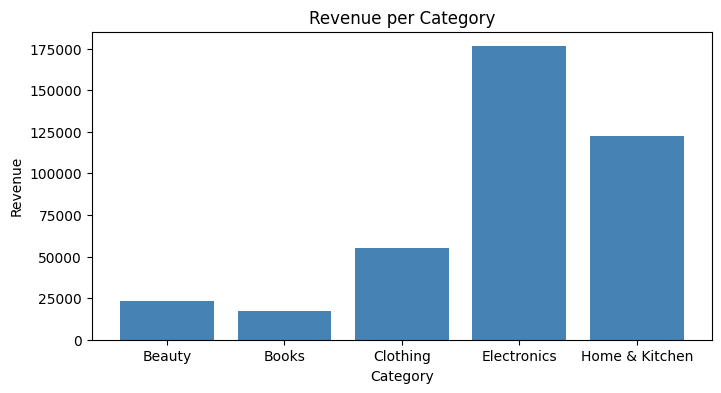

In [13]:
import matplotlib.pyplot as plt

catagory_revenue = df_sales.groupby('category')['revenue'].sum()

plt.figure(figsize = (8,4))
plt.bar(catagory_revenue.index,catagory_revenue.values,color = 'steelblue')
plt.title('Revenue per Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()